Data exploration

In [15]:
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa

# Define the number of rows you want to read
num_rows_to_read = 1_000_000
file_path = '../data/malaysia_transactions.parquet'

print(f"Loading the first {num_rows_to_read:,} transactions from '{file_path}'...")

# This memory-efficient approach reads the Parquet file in chunks (row groups)
# instead of loading the entire file into memory at once.
try:
    pf = pq.ParquetFile(file_path)

    # Read row groups until we have enough rows
    rows_read = 0
    batches = []
    for i in range(pf.num_row_groups):
        if rows_read >= num_rows_to_read:
            break
        
        table = pf.read_row_group(i)
        batches.append(table)
        rows_read += len(table)

    # Combine the read parts and trim to the exact size
    if batches:
        full_table = pa.concat_tables(batches)
        df = full_table.to_pandas()
        df = df.head(num_rows_to_read).copy()
        print(f"Successfully loaded {len(df):,} transactions.")
    else:
        df = pd.DataFrame()
        print("Warning: No data was loaded.")

except Exception as e:
    print(f"An error occurred: {e}")
    print("Falling back to the original method for a smaller subset.")
    # Fallback for any issues (e.g., file format), reads the first 1M rows directly
    df = pd.read_parquet(file_path)
    df = df.head(num_rows_to_read).copy()




Loading the first 1,000,000 transactions from '../data/malaysia_transactions.parquet'...
Successfully loaded 1,000,000 transactions.


In [16]:

# Set the option to display all columns
pd.set_option('display.max_columns', None)
# Preview
print(df.head())
print(df.info())

print("\n" + "="*50)
print("=== All Column Names in Dataset ===")
print("Available columns:", list(df.columns))


# Get the number of columns
num_columns = len(df.columns)

print(f"The DataFrame has {num_columns} columns.")
print(f"Missing ofi_account_type , rfi_account_type but got extra service code and service name")
# Output: The DataFrame has 3 columns.

                                trxn_id           date_time  ofi_acct_number  \
0  efa142dd-460e-4a47-928f-00da822cc479 2025-06-26 16:23:10   SB367351043121   
1  a7fcc7f9-644d-4de3-84e0-addcd5472f51 2025-06-26 19:13:24  FSB680204895602   
2  44d41e98-2cc0-4198-8924-e5dccf1f687e 2025-06-28 06:30:10   SB111553054019   
3  43bf8456-349b-4cf4-a40a-b7377a915a67 2025-06-20 14:11:23   SB026082802326   
4  8f7022cd-3450-4686-a299-1ac9a9f0e4d4 2025-06-02 06:39:48   SB553846781254   

         ofi_bank_code   ofi_entity_id ofi_entity_type rfi_acct_number  \
0        Selangor Bank  661119-01-7377        Personal  BS793483278866   
1  First Selangor Bank  670529-02-6381        Personal  BP198107986150   
2        Selangor Bank  891101-07-6618        Personal  BJ991281364892   
3        Selangor Bank  791018-10-7801        Personal  BJ991281364892   
4        Selangor Bank  700624-08-6856        Personal  BJ991281364892   

     rfi_bank_code rfi_entity_id rfi_entity_type  trxn_amount trxn_channel

In [17]:
# Count unique values for service_code and related columns
print("=== SERVICE_CODE Value Counts ===")
print(df['service_code'].value_counts())
print(f"\nTotal unique service_code values: {df['service_code'].nunique()}")

print("\n" + "="*50)
print("=== SERVICE_NAME Value Counts ===")
print(df['service_name'].value_counts())
print(f"\nTotal unique service_name values: {df['service_name'].nunique()}")



=== SERVICE_CODE Value Counts ===
service_code
9999    321489
030     221735
010     204909
040     186371
None     47627
070      11276
110       4036
031       2452
111         56
011         47
012          1
060          1
Name: count, dtype: int64

Total unique service_code values: 12

=== SERVICE_NAME Value Counts ===
service_name
Withdrawal    33325
Transfer      14302
Name: count, dtype: int64

Total unique service_name values: 2


In [18]:
# Analyze relationship between service_code and service_name
print("="*80)
print("SERVICE_CODE vs SERVICE_NAME RELATIONSHIP ANALYSIS")
print("="*80)

# 1. Basic counts for each column
print("1. BASIC STATISTICS:")
print("-" * 40)
print(f"Total transactions: {len(df):,}")
print(f"Unique service_codes: {df['service_code'].nunique()}")
print(f"Unique service_names: {df['service_name'].nunique()}")

print(f"\nService_code value counts:")
print(df['service_code'].value_counts())

print(f"\nService_name value counts:")
print(df['service_name'].value_counts())

# 2. Cross-tabulation to see relationship
print(f"\n2. CROSS-TABULATION (SERVICE_CODE vs SERVICE_NAME):")
print("-" * 40)
cross_tab = pd.crosstab(df['service_code'], df['service_name'], margins=True, dropna=False)
print(cross_tab)

# 3. Check for null values
print(f"\n3. NULL VALUE ANALYSIS:")
print("-" * 40)
print(f"service_code null values: {df['service_code'].isnull().sum():,}")
print(f"service_name null values: {df['service_name'].isnull().sum():,}")
print(f"service_name 'None' values: {(df['service_name'] == 'None').sum():,}")

# 4. Look for transactions where service_name is NOT None
print(f"\n4. TRANSACTIONS WITH NON-NULL SERVICE_NAME:")
print("-" * 40)
non_none_service_name = df[df['service_name'] != 'None']
if len(non_none_service_name) > 0:
    print(f"Found {len(non_none_service_name):,} transactions with actual service names")
    print("\nUnique service_name values (excluding 'None'):")
    print(non_none_service_name['service_name'].value_counts())
    
    print(f"\nSample of transactions with service names:")
    sample_cols = ['service_code', 'service_name', 'trxn_type', 'trxn_channel', 'trxn_amount', 'rfi_entity_name']
    print(non_none_service_name[sample_cols].head(10))
else:
    print("No transactions found with service_name other than 'None'")

# 5. Detailed relationship analysis
print(f"\n5. DETAILED RELATIONSHIP MAPPING:")
print("-" * 40)
relationship_df = df.groupby(['service_code', 'service_name']).agg({
    'trxn_id': 'count',
    'trxn_amount': ['mean', 'sum'],
    'trxn_type': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'N/A',
    'trxn_channel': lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'N/A'
}).reset_index()

relationship_df.columns = ['service_code', 'service_name', 'transaction_count', 'avg_amount', 'total_amount', 'most_common_type', 'most_common_channel']
relationship_df = relationship_df.sort_values('transaction_count', ascending=False)
print(relationship_df)

# 6. Check if there are patterns with other columns
print(f"\n6. SERVICE_CODE PATTERNS WITH OTHER FIELDS:")
print("-" * 40)
print("Service codes by transaction channel:")
channel_service = pd.crosstab(df['trxn_channel'], df['service_code'], margins=True)
print(channel_service)

# 7. Sample analysis - show examples of each service_code
print(f"\n7. SAMPLE TRANSACTIONS FOR EACH SERVICE_CODE:")
print("-" * 40)
for code in df['service_code'].unique():
    print(f"\nService Code: {code}")
    sample = df[df['service_code'] == code][['service_code', 'service_name', 'trxn_type', 'trxn_channel', 'trxn_amount']].head(3)
    print(sample)

SERVICE_CODE vs SERVICE_NAME RELATIONSHIP ANALYSIS
1. BASIC STATISTICS:
----------------------------------------
Total transactions: 1,000,000
Unique service_codes: 12
Unique service_names: 2

Service_code value counts:
service_code
9999    321489
030     221735
010     204909
040     186371
None     47627
070      11276
110       4036
031       2452
111         56
011         47
012          1
060          1
Name: count, dtype: int64

Service_name value counts:
service_name
Withdrawal    33325
Transfer      14302
Name: count, dtype: int64

2. CROSS-TABULATION (SERVICE_CODE vs SERVICE_NAME):
----------------------------------------
service_name  Transfer  Withdrawal     NaN      All
service_code                                       
010                  0           0  204909   204909
011                  0           0      47       47
012                  0           0       1        1
030                  0           0  221735   221735
031                  0           0    2452     2

In [19]:
# Additional analysis to understand service code meaning
print(f"\n" + "="*80)
print("ADVANCED SERVICE_CODE PATTERN ANALYSIS")
print("="*80)

# Group by service_code and analyze patterns
service_analysis = df.groupby('service_code').agg({
    'trxn_amount': ['count', 'mean', 'median', 'min', 'max', 'std'],
    'trxn_type': lambda x: list(x.unique()),
    'trxn_channel': lambda x: list(x.unique()),
    'service_name': lambda x: list(x.unique()),
    'ofi_participant_type': lambda x: list(x.unique()),
    'rfi_participant_type': lambda x: list(x.unique())
}).round(2)

print("Service Code Analysis Summary:")
print(service_analysis)

# Check if service codes correlate with amount ranges
print(f"\nService Code by Amount Ranges:")
df['amount_range'] = pd.cut(df['trxn_amount'], 
                           bins=[0, 10, 50, 100, 500, 1000, float('inf')], 
                           labels=['0-10', '10-50', '50-100', '100-500', '500-1000', '1000+'])

amount_service = pd.crosstab(df['amount_range'], df['service_code'], margins=True)
print(amount_service)


ADVANCED SERVICE_CODE PATTERN ANALYSIS
Service Code Analysis Summary:
             trxn_amount                                                \
                   count    mean  median     min         max       std   
service_code                                                             
010               204909  639.68  500.00    1.15  9999982.70  25516.05   
011                   47   20.26    7.00    1.15      500.00     72.47   
012                    1    7.00    7.00    7.00        7.00       NaN   
030               221735   27.96    7.00    1.15     7906.24    114.25   
031                 2452   46.78    7.00    1.15     2655.00    147.52   
040               186371   53.06    7.00    1.15     5720.00    161.10   
060                    1  500.00  500.00  500.00      500.00       NaN   
070                11276   81.58   25.66    1.15     6368.00    195.26   
110                 4036  385.72  500.00    1.15    29990.00    700.08   
111                   56  644.20  500.00 

In [20]:
print(df.isnull().sum())

trxn_id                      0
date_time                    0
ofi_acct_number              0
ofi_bank_code                0
ofi_entity_id            32895
ofi_entity_type          50184
rfi_acct_number          33325
rfi_bank_code            33325
rfi_entity_id            34732
rfi_entity_type          50184
trxn_amount                  0
trxn_channel                 0
trxn_type                50184
service_code                 0
service_name            952373
ofi_entity_name              0
rfi_entity_name          33325
ofi_participant_type         0
rfi_participant_type         0
amount_range                 0
dtype: int64


In [21]:
df = df.dropna(subset=['ofi_acct_number', 'rfi_acct_number', 'trxn_amount', 'ofi_entity_id', 'rfi_entity_id']).copy()

In [22]:
print(df.isnull().sum())

trxn_id                      0
date_time                    0
ofi_acct_number              0
ofi_bank_code                0
ofi_entity_id                0
ofi_entity_type           4801
rfi_acct_number              0
rfi_bank_code                0
rfi_entity_id                0
rfi_entity_type           4801
trxn_amount                  0
trxn_channel                 0
trxn_type                 4801
service_code                 0
service_name            949856
ofi_entity_name              0
rfi_entity_name              0
ofi_participant_type         0
rfi_participant_type         0
amount_range                 0
dtype: int64


In [23]:
from sklearn.preprocessing import LabelEncoder


# --- Encoding Block ---

# List of all categorical columns you want to encode
categorical_cols = ['service_code', 'service_name', 'trxn_type', 'trxn_channel']

print("Encoding categorical features...")

for col in categorical_cols:
    # 1. Fill missing values with 'Unknown'
    df[col] = df[col].fillna('Unknown')
    
    # 2. Create and apply the LabelEncoder
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    
    print(f"'{col}_enc' created successfully.")

print("\n--- Sample of Original and Encoded Columns ---")
# Display a sample to verify the encoding worked
print(df[['service_code', 'service_code_enc', 'trxn_type', 'trxn_type_enc']].head())

Encoding categorical features...
'service_code_enc' created successfully.
'service_name_enc' created successfully.
'trxn_type_enc' created successfully.
'trxn_channel_enc' created successfully.

--- Sample of Original and Encoded Columns ---
  service_code  service_code_enc     trxn_type  trxn_type_enc
0         9999                 7  Card Payment              0
1         9999                 7  Card Payment              0
2         9999                 7  Card Payment              0
3         9999                 7  Card Payment              0
4         9999                 7  Card Payment              0


In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

def fast_df_to_pyg_graph(df, all_accounts_map, make_masks=True):
    """
    Fast conversion of a DataFrame to a PyG Data object.
    all_accounts_map: dict mapping account IDs to node indices.
    make_masks: if True, create train/val masks (for training graph).
    """
    # Filter to only rows where both accounts are in the mapping
    mask = df['ofi_acct_number'].isin(all_accounts_map) & df['rfi_acct_number'].isin(all_accounts_map)
    df = df[mask]

    # Map account IDs to indices (vectorized)
    src_idx = df['ofi_acct_number'].map(all_accounts_map).to_numpy()
    dst_idx = df['rfi_acct_number'].map(all_accounts_map).to_numpy()
    edge_index = np.vstack([src_idx, dst_idx])

    # Edge features (as numpy arrays)
    edge_attr = df[['trxn_amount', 'service_code_enc']].to_numpy(dtype=np.float32)
    labels = df['is_fraud'].to_numpy(dtype=np.int64)

    # Convert to torch tensors
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    labels = torch.tensor(labels, dtype=torch.long)

    # Build PyG Data object
    data = Data(
        num_nodes=len(all_accounts_map),
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=labels
    )

    # Create train/val masks if needed (for training graph)
    if make_masks:
        num_edges = data.num_edges
        indices = np.arange(num_edges)
        stratify_labels = labels.numpy() if len(np.unique(labels)) > 1 else None

        train_indices, val_indices = train_test_split(
            indices, test_size=0.25, random_state=42, stratify=stratify_labels
        )
        train_mask = torch.zeros(num_edges, dtype=torch.bool)
        val_mask = torch.zeros(num_edges, dtype=torch.bool)
        train_mask[train_indices] = True
        val_mask[val_indices] = True
        data.train_mask = train_mask
        data.val_mask = val_mask

    return data

In [34]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

def fast_df_to_pyg_graph(df, all_accounts_map, make_masks=True):
    """
    Fast conversion of a DataFrame to a PyG Data object.
    all_accounts_map: dict mapping account IDs to node indices.
    make_masks: if True, create train/val masks (for training graph).
    """
    # Filter to only rows where both accounts are in the mapping
    mask = df['ofi_acct_number'].isin(all_accounts_map) & df['rfi_acct_number'].isin(all_accounts_map)
    df = df[mask]

    # Map account IDs to indices (vectorized)
    src_idx = df['ofi_acct_number'].map(all_accounts_map).to_numpy()
    dst_idx = df['rfi_acct_number'].map(all_accounts_map).to_numpy()
    edge_index = np.vstack([src_idx, dst_idx])

    # Edge features (as numpy arrays)
    edge_attr = df[['trxn_amount', 'service_code_enc']].to_numpy(dtype=np.float32)
    labels = df['is_fraud'].to_numpy(dtype=np.int64)

    # Convert to torch tensors
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    labels = torch.tensor(labels, dtype=torch.long)

    # Build PyG Data object
    data = Data(
        num_nodes=len(all_accounts_map),
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=labels
    )

    # Create train/val masks if needed (for training graph)
    if make_masks:
        num_edges = data.num_edges
        indices = np.arange(num_edges)
        stratify_labels = labels.numpy() if len(np.unique(labels)) > 1 else None

        train_indices, val_indices = train_test_split(
            indices, test_size=0.25, random_state=42, stratify=stratify_labels
        )
        train_mask = torch.zeros(num_edges, dtype=torch.bool)
        val_mask = torch.zeros(num_edges, dtype=torch.bool)
        train_mask[train_indices] = True
        val_mask[val_indices] = True
        data.train_mask = train_mask
        data.val_mask = val_mask

    return data

In [35]:

import numpy as np
import random

# Assume 'df' is your preprocessed and cleaned DataFrame
# Make sure you have a list of all unique accounts
all_accounts = pd.unique(df[['ofi_acct_number', 'rfi_acct_number']].values.ravel('K'))
print(f"Working with {len(all_accounts)} unique accounts.")

Working with 1116289 unique accounts.


In [36]:
def generate_synthetic_smurfing(accounts, num_smurfing_sets=10):
    synthetic_transactions = []
    
    for _ in range(num_smurfing_sets):
        # 1. Select a "mule" account to receive the funds
        mule_account = random.choice(accounts)
        
        # 2. Select several "smurf" accounts to send the funds
        num_smurfs = random.randint(10, 20)
        smurf_accounts = random.sample([acc for acc in accounts if acc != mule_account], num_smurfs)
        
        # 3. Create the smurfing transactions
        for smurf_account in smurf_accounts:
            transaction = {
                'ofi_acct_number': smurf_account,
                'rfi_acct_number': mule_account,
                'trxn_amount': round(random.uniform(10, 99), 2),  # Small, random amounts
                'is_fraud': 1, # This is a fraudulent transaction
                # Add other necessary features with realistic default values
                'service_code_enc': 0, # Example default
                'date_time': pd.Timestamp.now()
            }
            synthetic_transactions.append(transaction)
            
    return pd.DataFrame(synthetic_transactions)

In [37]:
def generate_synthetic_cycles(accounts, num_cycles=20):
    synthetic_transactions = []
    
    for _ in range(num_cycles):
        # 1. Define the length of the cycle
        cycle_length = random.randint(3, 5)
        
        # 2. Select unique accounts for the cycle
        if len(accounts) < cycle_length:
            continue # Not enough accounts to form a cycle
        
        cycle_accounts = random.sample(list(accounts), cycle_length)
        
        # 3. Create the transactions forming the cycle
        for i in range(cycle_length):
            sender = cycle_accounts[i]
            receiver = cycle_accounts[(i + 1) % cycle_length] # Wrap around to complete the cycle
            
            transaction = {
                'ofi_acct_number': sender,
                'rfi_acct_number': receiver,
                'trxn_amount': round(random.uniform(100, 5000), 2),
                'is_fraud': 1,
                # Add other necessary features
                'service_code_enc': 1, # Example default
                'date_time': pd.Timestamp.now()
            }
            synthetic_transactions.append(transaction)
            
    return pd.DataFrame(synthetic_transactions)

In [38]:

def generate_synthetic_layering(accounts, num_chains=15, chain_length_range=(3, 6)):
    """
    Generates synthetic layering transactions.
    
    Args:
        accounts (list): A list of all unique account IDs to use for generating transactions.
        num_chains (int): The number of separate layering chains to create.
        chain_length_range (tuple): A (min, max) tuple for the number of accounts in a chain.
    
    Returns:
        pandas.DataFrame: A DataFrame containing the synthetic layering transactions.
    """
    synthetic_transactions = []
    
    for _ in range(num_chains):
        # 1. Define the length of the layering chain
        chain_length = random.randint(chain_length_range[0], chain_length_range[1])
        
        # 2. Select unique accounts for the chain
        if len(accounts) < chain_length:
            continue # Not enough accounts to form the chain
            
        chain_accounts = random.sample(list(accounts), chain_length)
        
        # 3. Define the initial transaction amount
        initial_amount = round(random.uniform(5000, 20000), 2)
        
        # 4. Create the transactions forming the chain
        current_amount = initial_amount
        for i in range(chain_length - 1):
            sender = chain_accounts[i]
            receiver = chain_accounts[i+1]
            
            # Slightly alter the amount at each step to make it more realistic
            current_amount *= random.uniform(0.95, 0.99)
            
            transaction = {
                'ofi_acct_number': sender,
                'rfi_acct_number': receiver,
                'trxn_amount': round(current_amount, 2),
                'is_fraud': 1, # Label this transaction as fraudulent
                # Add other necessary features with default values
                'service_code_enc': 2, # Use a different code to distinguish if needed
                'date_time': pd.Timestamp.now()
            }
            synthetic_transactions.append(transaction)
            
    return pd.DataFrame(synthetic_transactions)

In [39]:
from sklearn.model_selection import train_test_split

# Assume 'df' is your clean, real-world transaction data
# If you have pre-labeled real fraud, keep those labels.
# Otherwise, assume all real data is not fraudulent for now.
if 'is_fraud' not in df.columns:
    df['is_fraud'] = 0

print("Original real-world data shape:", df.shape)

# Split the REAL data into a training set and a final test set (e.g., 80/20 split)
# We use stratify to maintain the same proportion of any existing real fraud in both sets.
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['is_fraud'] if df['is_fraud'].nunique() > 1 else None # Stratify only if there are both 0s and 1s
)

print(f"Real training data shape: {train_df.shape}")
print(f"Real test data shape:     {test_df.shape}")
print("\nTest set will be kept separate and untouched.")

Original real-world data shape: (954617, 25)
Real training data shape: (763693, 25)
Real test data shape:     (190924, 25)

Test set will be kept separate and untouched.


In [40]:
print("Generating synthetic fraud...")
synthetic_smurfing_df = generate_synthetic_smurfing(all_accounts, num_smurfing_sets=20)
synthetic_cycles_df = generate_synthetic_cycles(all_accounts, num_cycles=50)
synthetic_layering_df = generate_synthetic_layering(all_accounts, num_chains=30) 


# Get a list of all unique accounts from the full, real dataset
all_accounts = pd.unique(df[['ofi_acct_number', 'rfi_acct_number']].values.ravel('K'))


synthetic_fraud_df = pd.concat([synthetic_smurfing_df, synthetic_cycles_df,synthetic_layering_df], ignore_index=True)
print(f"\nGenerated {len(synthetic_fraud_df)} synthetic fraud transactions.")

Generating synthetic fraud...

Generated 576 synthetic fraud transactions.


In [41]:
# Combine the real training data with the synthetic fraud data
augmented_train_df = pd.concat([train_df, synthetic_fraud_df], ignore_index=True)

# Shuffle the augmented training set to mix real and synthetic data
augmented_train_df = augmented_train_df.sample(frac=1).reset_index(drop=True)

print("\n--- Final Datasets ---")
print(f"Augmented Training Set Shape: {augmented_train_df.shape}")
print("Augmented Training Set Composition:")
print(augmented_train_df['is_fraud'].value_counts())

print(f"\nUntouched Test Set Shape: {test_df.shape}")
print("Untouched Test Set Composition:")
print(test_df['is_fraud'].value_counts())


--- Final Datasets ---
Augmented Training Set Shape: (764269, 25)
Augmented Training Set Composition:
is_fraud
0    763693
1       576
Name: count, dtype: int64

Untouched Test Set Shape: (190924, 25)
Untouched Test Set Composition:
is_fraud
0    190924
Name: count, dtype: int64


In [42]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

#build graph

def fast_df_to_pyg_graph(df, all_accounts_map, make_masks=True):
    """
    Fast conversion of a DataFrame to a PyG Data object.
    all_accounts_map: dict mapping account IDs to node indices.
    make_masks: if True, create train/val masks (for training graph).
    """
    # Filter to only rows where both accounts are in the mapping
    mask = df['ofi_acct_number'].isin(all_accounts_map) & df['rfi_acct_number'].isin(all_accounts_map)
    df = df[mask]

    # Map account IDs to indices (vectorized)
    src_idx = df['ofi_acct_number'].map(all_accounts_map).to_numpy()
    dst_idx = df['rfi_acct_number'].map(all_accounts_map).to_numpy()
    edge_index = np.vstack([src_idx, dst_idx])

    # Edge features (as numpy arrays)
    edge_attr = df[['trxn_amount', 'service_code_enc']].to_numpy(dtype=np.float32)
    labels = df['is_fraud'].to_numpy(dtype=np.int64)

    # Convert to torch tensors
    edge_index = torch.tensor(edge_index, dtype=torch.long)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    labels = torch.tensor(labels, dtype=torch.long)

    # Build PyG Data object
    data = Data(
        num_nodes=len(all_accounts_map),
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=labels
    )

    # Create train/val masks if needed (for training graph)
    if make_masks:
        num_edges = data.num_edges
        indices = np.arange(num_edges)
        stratify_labels = labels.numpy() if len(np.unique(labels)) > 1 else None

        train_indices, val_indices = train_test_split(
            indices, test_size=0.25, random_state=42, stratify=stratify_labels
        )
        train_mask = torch.zeros(num_edges, dtype=torch.bool)
        val_mask = torch.zeros(num_edges, dtype=torch.bool)
        train_mask[train_indices] = True
        val_mask[val_indices] = True
        data.train_mask = train_mask
        data.val_mask = val_mask

    return data

In [43]:
class EdgeClassifier(torch.nn.Module):
    def __init__(self, num_nodes, hidden_channels):
        super().__init__()
        # A single embedding layer for all nodes in the system
        self.node_emb = torch.nn.Embedding(num_nodes, hidden_channels)
        
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(2 * hidden_channels, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(hidden_channels, 2) # 2 classes: fraud (1) vs. non-fraud (0)
        )

    def forward(self, x, edge_index):
        # The GNN layers produce node embeddings based on message passing
        h = self.conv1(x, edge_index).relu()
        h = self.conv2(h, edge_index)
        
        # Use the final node embeddings to predict edge properties
        source_emb = h[edge_index[0]]
        dest_emb = h[edge_index[1]]
        edge_emb = torch.cat([source_emb, dest_emb], dim=-1)
        
        return self.classifier(edge_emb)

    def full_pass(self, data):
        # Helper function to get predictions for a whole graph
        # It starts with the initial embeddings and passes them through the GNN
        x = self.node_emb(torch.arange(data.num_nodes, device=data.edge_index.device))
        return self.forward(x, data.edge_index)

In [44]:

print("Building graphs...")
all_accounts_map = {acc: i for i, acc in enumerate(all_accounts)}

# Build the training graph (with train/val masks) and the test graph (without)
train_graph = fast_df_to_pyg_graph(augmented_train_df, all_accounts_map, make_masks=True)
test_graph = fast_df_to_pyg_graph(test_df, all_accounts_map, make_masks=False)

print("\n--- Graphs Created ---")
print("Training Graph:", train_graph)
print("Test Graph:    ", test_graph)


# --- Model Initialization ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EdgeClassifier(num_nodes=len(all_accounts_map), hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
# Use weighted loss for imbalanced classes
weights = torch.tensor([1.0, 10.0]).to(device) # Give more weight to the fraud class (1)
criterion = torch.nn.CrossEntropyLoss(weight=weights)


train_graph = train_graph.to(device)
test_graph = test_graph.to(device)


Building graphs...

--- Graphs Created ---
Training Graph: Data(edge_index=[2, 764269], edge_attr=[764269, 2], y=[764269], num_nodes=1116289, train_mask=[764269], val_mask=[764269])
Test Graph:     Data(edge_index=[2, 190924], edge_attr=[190924, 2], y=[190924], num_nodes=1116289)


In [49]:
def train():
    model.train()
    optimizer.zero_grad()
    
    # Use the full training graph for message passing
    out = model.full_pass(train_graph)
    
    # Calculate loss only on the training edges
    loss = criterion(out[train_graph.train_mask], train_graph.y[train_graph.train_mask])
    loss.backward()
    optimizer.step()
    return float(loss)

@torch.no_grad()
def test(graph_data, mask=None):
    """Evaluates the model on a given graph and mask."""
    model.eval()
    
    out = model.full_pass(graph_data)
    pred_proba = F.softmax(out, dim=-1)[:, 1] # Probability of being fraud
    pred_class = out.argmax(dim=-1)

    #Use the provided mask or evaluate on the whole graph
    y_true = graph_data.y if mask is None else graph_data.y[mask]
    y_pred_class = pred_class if mask is None else pred_class[mask]
    y_pred_proba = pred_proba if mask is None else pred_proba[mask]
    
     #Calculate metrics
    f1 = f1_score(y_true.cpu(), y_pred_class.cpu())
    roc_auc = roc_auc_score(y_true.cpu(), y_pred_proba.cpu())
    
    return f1, roc_auc

In [50]:
print("\n--- Starting Model Training ---")
for epoch in range(1, 101):
    loss = train()
    
    if epoch % 10 == 0:
        # Evaluate on the validation set within the training graph
        val_f1, val_auc = test(train_graph, train_graph.val_mask)
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val F1: {val_f1:.4f}, Val AUC: {val_auc:.4f}')

print("\n--- Final Model Evaluation on Untouched Test Data ---")
# Evaluate on the separate, real-world test graph
test_f1, test_auc = test(test_graph)
print(f'Test Set F1-Score: {test_f1:.4f}')
print(f'Test Set ROC-AUC:  {test_auc:.4f}')

@torch.no_grad()
def test(graph_data, mask=None):
    """Evaluates the model on a given graph and mask."""
    model.eval()
    
    out = model.full_pass(graph_data)
    pred_proba = F.softmax(out, dim=-1)[:, 1] # Probability of being fraud
    pred_class = out.argmax(dim=-1)

    y_true = graph_data.y if mask is None else graph_data.y[mask]
    y_pred_class = pred_class if mask is None else pred_class[mask]
    y_pred_proba = pred_proba if mask is None else pred_proba[mask]
    
    # --- FIX IS HERE ---
    # Calculate metrics only if both classes are present
    f1 = f1_score(y_true.cpu(), y_pred_class.cpu(), zero_division=0)
    
    # Check if there are at least two classes in the true labels
    if len(torch.unique(y_true)) > 1:
        roc_auc = roc_auc_score(y_true.cpu(), y_pred_proba.cpu())
    else:
        # If only one class, AUC is not defined. We can report it as 0.5 (random) or NaN.
        roc_auc = 0.5 
    
    return f1, roc_auc


--- Starting Model Training ---
Epoch: 010, Loss: 0.0220, Val F1: 0.0135, Val AUC: 0.9224
Epoch: 020, Loss: 0.0157, Val F1: 0.1498, Val AUC: 0.9194
Epoch: 030, Loss: 0.0091, Val F1: 0.0864, Val AUC: 0.9187
Epoch: 040, Loss: 0.0034, Val F1: 0.2036, Val AUC: 0.9123
Epoch: 050, Loss: 0.0009, Val F1: 0.1781, Val AUC: 0.9101
Epoch: 060, Loss: 0.0005, Val F1: 0.1809, Val AUC: 0.9098
Epoch: 070, Loss: 0.0003, Val F1: 0.1882, Val AUC: 0.9109
Epoch: 080, Loss: 0.0003, Val F1: 0.1953, Val AUC: 0.9117
Epoch: 090, Loss: 0.0002, Val F1: 0.1966, Val AUC: 0.9119
Epoch: 100, Loss: 0.0002, Val F1: 0.1974, Val AUC: 0.9120

--- Final Model Evaluation on Untouched Test Data ---
Test Set F1-Score: 0.0000
Test Set ROC-AUC:  nan


c:\Users\adamt\Documents\UM degree\y3s2\payHack\gosel-dashboard\backend\venv\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [51]:
# --- Creating a blended test set for evaluation ---

# Take a small sample of your synthetic fraud
num_synthetic_in_test = 50 
test_synthetic_fraud = synthetic_fraud_df.sample(n=num_synthetic_in_test)

# Combine the real test data with a small amount of synthetic fraud
blended_test_df = pd.concat([test_df, test_synthetic_fraud], ignore_index=True)

# Create a new graph for this blended test set
blended_test_graph = fast_df_to_pyg_graph(blended_test_df, all_accounts_map, make_masks=False)
blended_test_graph = blended_test_graph.to(device)


# --- Now, evaluate on this blended graph ---
print("\n--- Evaluation on a Blended Test Set (Real + Synthetic) ---")
blended_f1, blended_auc = test(blended_test_graph)
print(f'Blended Test Set F1-Score: {blended_f1:.4f}')
print(f'Blended Test Set ROC-AUC:  {blended_auc:.4f}')


--- Evaluation on a Blended Test Set (Real + Synthetic) ---
Blended Test Set F1-Score: 0.1023
Blended Test Set ROC-AUC:  0.9465


In [52]:
import torch
import torch.nn.functional as F

@torch.no_grad()
def get_predictions(graph_data):
    """Runs the model on a graph and returns true labels and predictions."""
    model.eval()
    
    # Get the model's output probabilities
    out = model.full_pass(graph_data)
    
    # Get the predicted class by finding the index with the highest probability
    preds = out.argmax(dim=-1)
    
    # Get the true labels
    labels = graph_data.y
    
    return labels.cpu().numpy(), preds.cpu().numpy()

--- Confusion Matrix ---
The matrix shows: [[TN, FP], [FN, TP]]
[[190473    451]
 [    23     27]]

Where:
TN (True Negatives): Correctly identified Non-Fraud
FP (False Positives): Incorrectly identified as Fraud
FN (False Negatives): Missed Fraud
TP (True Positives): Correctly identified Fraud


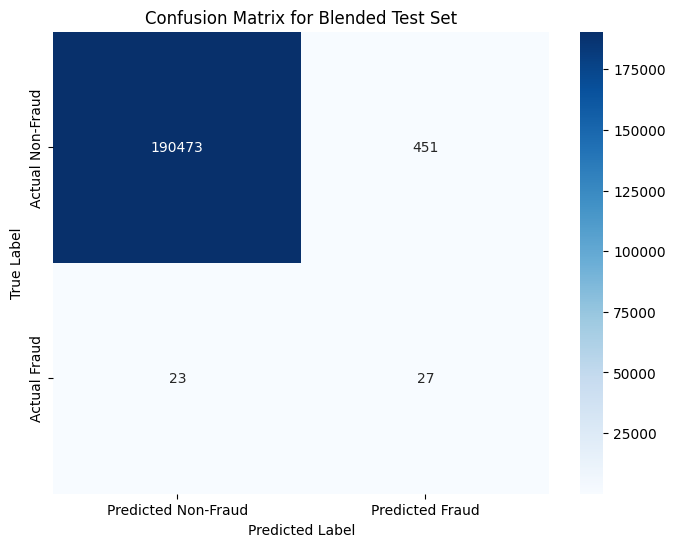

In [53]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Ensure you have a 'blended_test_graph' from the previous step ---
# It should contain a mix of real data and some synthetic fraud.
# blended_test_graph = fast_df_to_pyg_graph(blended_test_df, ...).to(device)


# 1. Get the predictions for the blended test set
true_labels, predicted_labels = get_predictions(blended_test_graph)

# 2. Calculate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

print("--- Confusion Matrix ---")
print("The matrix shows: [[TN, FP], [FN, TP]]")
print(cm)
print("\nWhere:")
print("TN (True Negatives): Correctly identified Non-Fraud")
print("FP (False Positives): Incorrectly identified as Fraud")
print("FN (False Negatives): Missed Fraud")
print("TP (True Positives): Correctly identified Fraud")


# 3. (Optional but Recommended) Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Fraud', 'Predicted Fraud'],
            yticklabels=['Actual Non-Fraud', 'Actual Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Blended Test Set')
plt.show()